# 3 Convolutional neural networks

We will first apply a small filter to an image and then train a one-dimensional CNN to detect a motif in DNA sequences. The sequences are generated artificially and the labels indicate the presence of an exact string. They are not experimentally measured promoter annotations.

In [1]:
import random
import numpy as np
import torch

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.set_num_threads(2)

seed_everything(42)

## 3.1 A filter is a small pattern detector
Start with a tiny artificial image containing a vertical stripe. A 3 × 3 filter examines neighboring pixels with the same weights wherever it moves. This **parameter sharing** is the key idea of convolution.

The filter here is hand-written, so we know what it detects. A CNN learns filter weights from training examples. PyTorch's operation is technically cross-correlation (the kernel is not flipped), conventionally called convolution in neural networks.

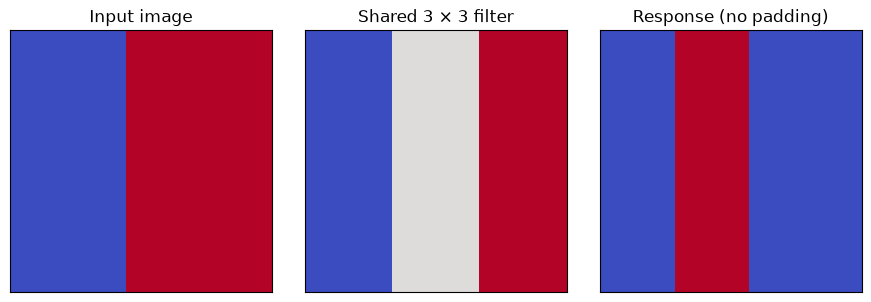

In [2]:
import numpy as np, pandas as pd, torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
image = torch.zeros(1, 1, 9, 9)
image[:, :, :, 4:] = 1
filter_2d = torch.tensor([[-1., 0., 1.], [-1., 0., 1.], [-1., 0., 1.]]).reshape(1, 1, 3, 3)
response = F.conv2d(image, filter_2d)
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, values, title in zip(axes, [image[0, 0], filter_2d[0, 0], response[0, 0]],
                              ["Input image", "Shared 3 × 3 filter", "Response (no padding)"]):
    ax.imshow(values, cmap="coolwarm")
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

*Assignment: Move the pattern*

If the vertical boundary moves two pixels right, what happens to the filter response? How might this help with microscopy images?

*Answer:*

The response moves with the boundary. The same filter can detect a local pattern at multiple positions. Images require other considerations, including scale, rotations and acquisition differences. Shared filters do not automatically make a model robust to every transformation.

## 3.2 Represent DNA without inventing an ordering of bases
Encoding A=0, C=1, G=2 and T=3 as continuous measurements would suggest a numerical ordering. Instead, **one-hot encoding** gives each base its own channel.

Each position has four numbers: one is 1 and the others are 0. For `Conv1d`, the shape is **(examples, 4 base channels, sequence positions)**. Our sequences have the same length, so this exercise needs no padding.

In [3]:
DNA_ALPHABET = "ACGT"
MOTIF = "TATAAA"

def one_hot_dna(sequences):
    mapping = {base: i for i, base in enumerate(DNA_ALPHABET)}
    indices = np.array([[mapping[base] for base in seq] for seq in sequences])
    # Conv1d expects (examples, channels, positions).
    return np.eye(4, dtype=np.float32)[indices].transpose(0, 2, 1).copy()

In [4]:
example = "ACGTAC"
encoded = one_hot_dna([example])
display(pd.DataFrame(encoded[0], index=list("ACGT"), columns=[f"{i}:{base}" for i, base in enumerate(example)]))
print("Shape:", encoded.shape)

,0:A,1:C,2:G,3:T,4:A,5:C
A,1.0,0.0,0.0,0.0,1.0,0.0
C,0.0,1.0,0.0,0.0,0.0,1.0
G,0.0,0.0,1.0,0.0,0.0,0.0
T,0.0,0.0,0.0,1.0,0.0,0.0


Shape: (1, 4, 6)


## 3.3 Generate separate data for each split
The generator creates random A/C/G/T backgrounds that do not already contain the motif. It inserts the motif at a random position in half the sequences. The labels are therefore exact motif presence, not measured biology.

Training, validation and test sequences are generated with different seeds. We check that none are exact duplicates across splits. The test arrays are kept aside until the evaluation cell.

In [5]:
DNA_ALPHABET = "ACGT"
MOTIF = "TATAAA"

def motif_data(n=1000, length=48, seed=42):
    """Artificial motif detection, not real regulatory annotation.

    Balanced classes; no background contains MOTIF. Positives receive one motif
    at a random position. Synthetic labels define exact motif presence.
    """
    rng = np.random.default_rng(seed)
    labels = np.arange(n) % 2
    rng.shuffle(labels)
    sequences = []
    for label in labels:
        while True:
            sequence = "".join(rng.choice(list(DNA_ALPHABET), size=length))
            if MOTIF not in sequence:
                break
        if label:
            position = int(rng.integers(0, length - len(MOTIF) + 1))
            sequence = sequence[:position] + MOTIF + sequence[position + len(MOTIF):]
        sequences.append(sequence)
    return sequences, labels.astype(np.float32)

In [6]:
train_sequences, y_train = motif_data(1000, seed=10)
val_sequences, y_val = motif_data(200, seed=11)
test_sequences, y_test = motif_data(200, seed=12)
assert not (set(train_sequences) & set(val_sequences))
assert not (set(train_sequences) & set(test_sequences))
assert not (set(val_sequences) & set(test_sequences))
for seqs, labels in [(train_sequences, y_train), (val_sequences, y_val), (test_sequences, y_test)]:
    assert all((MOTIF in sequence) == bool(label) for sequence, label in zip(seqs, labels))
x_train = one_hot_dna(train_sequences)
x_val = one_hot_dna(val_sequences)
display(pd.DataFrame({"sequence": train_sequences[:6], "motif_present": y_train[:6].astype(int)}))

,sequence,motif_present
0,GTGACTGATTTGTGATTATAAACTCAGATTTATACAGTAAGTTGACAC,1
1,TCATATACGACGTAGGCTTGGTCGCCCTGTTGTGGGCGCTTTTCCACT,0
2,CCTGGGCCCGGTAATGGACCGCTTAAACTGTCTACGCTTTACTTAGTA,0
3,TTACTATCTCTGTACTCCCAATCGACCTTGTATAAAGATCCTTTACTG,1
4,GAAGCATCATAGAGGTTTTCCGGTAGCTGTCCACCTGAATTGTAGAGC,0
5,GAATGTCGACTCGGTGACCAAGTGTGAATATAAAACGAGTACCTGCGG,1


## 3.4 Build a small CNN
Follow the shapes:

`(batch, 4, 48)` → filters of width 6 → `(batch, 16, 43)` → ReLU → maximum over positions → `(batch, 16)` → one logit.

**Global max pooling** keeps the strongest response from each filter. This helps answer "is a pattern anywhere in the sequence?" but discards its exact position and how often it appeared. No padding is used, so 48 positions become 48 − 6 + 1 = 43 windows.

In [7]:
class MotifCNN(nn.Module):
    def __init__(self, kernel_size=6, channels=16):
        super().__init__()
        self.conv = nn.Conv1d(4, channels, kernel_size)
        self.classifier = nn.Linear(channels, 1)

    def forward(self, x):
        local_responses = torch.relu(self.conv(x))
        strongest_response = local_responses.amax(dim=-1)
        return self.classifier(strongest_response)

seed_everything(42)
model = MotifCNN()
print("Parameters:", sum(p.numel() for p in model.parameters()))
print("Output shape:", model(torch.tensor(x_train[:3])).shape)

Parameters: 417
Output shape: torch.Size([3, 1])


## 3.5 Train the CNN
Only the architecture and input shape changed. The optimizer, binary loss, validation pass and evaluation logic are familiar.

In [8]:
from torch.utils.data import DataLoader, TensorDataset
from copy import deepcopy
from torch import nn
import pandas as pd
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

def loader(x, y, batch_size=32, shuffle=False, seed=42):
    return DataLoader(
        TensorDataset(torch.as_tensor(x, dtype=torch.float32), torch.as_tensor(y, dtype=torch.float32)),
        batch_size=batch_size, shuffle=shuffle,
        generator=torch.Generator().manual_seed(seed), num_workers=0,
    )

def fit_binary(model, train_loader, val_loader, epochs=30, lr=0.001, weight_decay=0.0):
    """CPU training for small exercises. Return independent best-validation weights.

    Models return ONE LOGIT per example. The loss includes the sigmoid.
    Loss means are weighted by sample count, including the last short batch.
    """
    loss_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    best_loss = float("inf")
    best_weights = deepcopy(model.state_dict())
    history = []
    for epoch in range(epochs):
        values = {}
        for phase, batches in [("train", train_loader), ("val", val_loader)]:
            model.train(phase == "train")
            total_loss, count = 0.0, 0
            with torch.set_grad_enabled(phase == "train"):
                for x, y in batches:
                    if phase == "train":
                        optimizer.zero_grad()
                    logits = model(x).squeeze(-1)
                    loss = loss_fn(logits, y)
                    if phase == "train":
                        loss.backward()
                        optimizer.step()
                    total_loss += loss.item() * len(y)
                    count += len(y)
            values[phase + "_loss"] = total_loss / count
        if values["val_loss"] < best_loss:
            best_loss = values["val_loss"]
            best_weights = deepcopy(model.state_dict())
        history.append({"epoch": epoch + 1, **values})
    model.load_state_dict(best_weights)
    model.eval()
    return pd.DataFrame(history)

@torch.no_grad()
def probabilities(model, x):
    model.eval()
    return torch.sigmoid(model(torch.as_tensor(x, dtype=torch.float32)).squeeze(-1)).numpy()

def binary_scores(y, probability):
    predicted = np.asarray(probability) >= 0.5
    return {
        "accuracy": accuracy_score(y, predicted),
        "balanced_accuracy": balanced_accuracy_score(y, predicted),
        "ROC_AUC": roc_auc_score(y, probability),
    }

def plot_history(history, title="Training and validation loss"):
    ax = history.plot(x="epoch", y=["train_loss", "val_loss"], figsize=(6, 3.5))
    ax.set(xlabel="Epoch (one pass through training data)", ylabel="Binary cross-entropy", title=title)
    plt.tight_layout()
    plt.show()

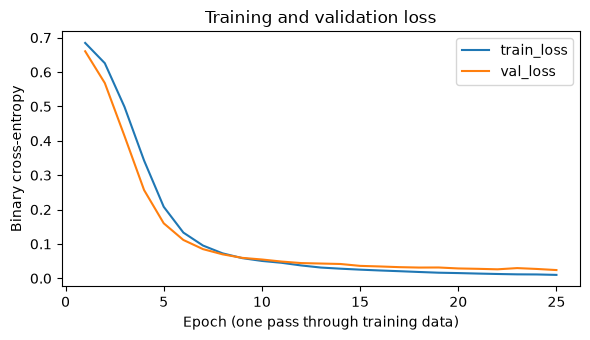

accuracy             0.99
balanced_accuracy    0.99
ROC_AUC              1.00
Name: Validation, dtype: float64

In [9]:
history = fit_binary(model, loader(x_train, y_train, batch_size=64, shuffle=True),
                     loader(x_val, y_val, batch_size=64), epochs=25, lr=0.01)
plot_history(history)
display(pd.Series(binary_scores(y_val, probabilities(model, x_val)), name="Validation"))

*Assignment: How much sequence does a filter see?*

Train a second model with kernel size 3. Compare with width 6 on validation. Can a single width-3 filter directly recognize all six bases of the motif?

In [10]:
seed_everything(42)
alternative = MotifCNN(kernel_size=3)
alternative_history = fit_binary(alternative, loader(x_train, y_train, batch_size=64, shuffle=True),
                                 loader(x_val, y_val, batch_size=64), epochs=25, lr=0.01)
display(pd.Series(binary_scores(y_val, probabilities(alternative, x_val)), name="Alternative validation"))

accuracy             0.9700
balanced_accuracy    0.9700
ROC_AUC              0.9701
Name: Alternative validation, dtype: float64

*Answer:*

A single width-3 filter sees only three positions. The pooled model may combine evidence for short fragments or composition, but it loses the relative positions needed to establish the full motif reliably. Deeper CNNs can expand receptive fields; CNNs are not inherently limited to only short-range dependencies.

## 3.6 Compare against a simple baseline
The motif is A/T-rich, so even base composition could carry some information. A useful baseline is logistic regression on four base fractions. This ignores sequence order and gives us a fair question: does the CNN learn beyond composition?

Choose the CNN using validation loss. The baseline has a fixed configuration. Now evaluate the two methods once on the same test sequences.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
baseline = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000, random_state=42))
baseline.fit(x_train.mean(axis=2), y_train)
chosen_cnn = model if history.val_loss.min() <= alternative_history.val_loss.min() else alternative
x_test = one_hot_dna(test_sequences)
results = {
    "Base-composition baseline": binary_scores(y_test, baseline.predict_proba(x_test.mean(axis=2))[:, 1]),
    "Selected CNN": binary_scores(y_test, probabilities(chosen_cnn, x_test)),
}
display(pd.DataFrame(results).T)

,accuracy,balanced_accuracy,ROC_AUC
Base-composition baseline,0.690,0.690,0.7461
Selected CNN,0.995,0.995,1.0000


*Assignment: What did we actually learn?*

Would strong performance prove that this CNN predicts promoter activity? Name two ways a real biological dataset differs from this generator.

*Answer:*

No. Labels here are exact occurrences of a string inserted into independent random backgrounds. Real regulation depends on context, multiple motifs, orientation, accessibility and experimental design; labels can be noisy. Train/test overlap from related sequences or shared experiments also needs attention. This exercise demonstrates learning a local pattern, not a validated biological predictor.

*Optional assignment: Translation and lost information*

Why does max pooling help when the motif moves, and what task would it make harder? How would you change the model for counting motifs?

*Answer:*

Max pooling retains the largest filter response regardless of location, except for edge effects. It discards counts and positions. Sum pooling, a position-aware output or a different architecture could suit counting, with a dataset designed to test counting rather than mere presence.